In [ ]:
# Libraries for working with images
import tqdm # progress bar
import torch
# !pip install monai
import monai # PyTorch and Monai are good combo for Xray and MRI
import cv2 # openai
from PIL import Image # Handle different type of images
import ipywidgets as widgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 59.8 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## Steps in setting up the enviroment
1. Clone my repo at [ai_brain_tumor_dashboard](https://github.com/jtran2509/ai_brain_tumor_dashboard)
2. Upload JSON file to retrive username and key from Kaggle
3. Download dataset from Kaggle and unzip them
4. Check for the number of files in the `ai_brain_tumor_dashboard` and `dataset` repos to make sure our dataset folder has images in it
5. Delete the `dataset` and the unzip file to make room for the disk (if all of the images are in there)
=> Whenever re-start the notebook, mount Drive and move directly into the `ai_brain_tumor_dashboard` folder

In [2]:
#1. Clone the repo
!git clone https://github.com/jtran2509/ai_brain_tumor_dashboard
%cd ai_brain_tumor_dashboard


Cloning into 'ai_brain_tumor_dashboard'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 48 (delta 14), reused 41 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 159.19 KiB | 17.69 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/ai_brain_tumor_dashboard


In [3]:
# Uploaded JSON file to retrieve username and key
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jadetran99","key":"eddc7e88b3ca00cf24c745a3010962c6"}'}

In [4]:
# Create the directory anbd set permission
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
# Download dataset from Kaggle
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

# Unzip the dataset quietly (-q) into a folder named 'dataset'
!unzip -q brain-tumor-mri-dataset.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 93% 146M/157M [00:00<00:00, 1.53GB/s]
100% 157M/157M [00:00<00:00, 1.50GB/s]


In [6]:
# See how many files in each folder, verify before deleting the unzip folder
!ls -R dataset | wc -l
!ls -R /content/ai_brain_tumor_dashboard | wc -l

# To double check, any files that start ends with `jpg` -> 7023 images
!find /content/ai_brain_tumor_dashboard/dataset -name "*.jpg" | wc -l

7231
7257
7200


In [7]:
# Remove the extra unzip folder that is outside the repo
!rm -rf /content/dataset

# Remove the downloaded zip file to save spaces
!rm -rf /content/brain-tumor-mri-dataset.zip

In [9]:
# After cloning Github repo and verify the dataset has enough images, mount Drive

from google.colab import drive
drive.mount('/content/drive')

# Change directory directly to our project in Drive
%cd /content/ai_brain_tumor_dashboard

Mounted at /content/drive
/content/ai_brain_tumor_dashboard


## EDA

What to do:
- Dataset size
- Class distribution (imbalance)
- Example images per class
- Image dimensions / channels
- Corrupted or unreadable files
- Train/val/test/split strategy
- Initial observations (noise, blur, artifacts, etc)

### Conclusions might be:
- Classes are quite balance


In [10]:
# Define data paths
import os

BASE_DIR = '/content/ai_brain_tumor_dashboard/dataset'
TRAINING_FOLDER = os.path.join(BASE_DIR, 'Training')
TESTING_FOLDER = os.path.join(BASE_DIR, 'Testing')
VAL_FOLDER = os.path.join(BASE_DIR, 'Validation')
CLASSES = sorted(os.listdir(TRAINING_FOLDER))


In [11]:
# Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries and packages accordingly for neural networks
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
# from torch.utils.data import DataLoader
from torch.utils.data.dataloader import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torchvision.datasets import ImageFolder


In [12]:
import tqdm # progress bar
import torch
import monai # PyTorch and Monai are good combo for Xray and MRI
import cv2 # openai
from PIL import Image # Handle different type of images
import ipywidgets as widgets

from monai.config import print_config
from monai.data import decollate_batch
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
    Resize,
    ToTensor
)

from monai.utils import set_determinism

In [13]:
import glob
import random
import shutil
from tqdm.auto import tqdm
import copy
import io
import PIL
from PIL import Image


In [14]:
# Create validation datset and move 10% of the training into validation folder
image_files = glob.glob(os.path.join(TRAINING_FOLDER, '**/*.jpg'), recursive= True)
num_classes = 4
selected_images = random.sample(image_files, int(len(image_files)*0.1))

In [15]:
#Move the selected images to the validation directory
for image_path in tqdm(selected_images):
    #Get the class name from parent directory
    class_folder = os.path.basename(os.path.dirname(image_path))

    # Create a new folder in the validation directory for the current class
    val_class_path = os.path.join(VAL_FOLDER, class_folder)
    if not os.path.exists(val_class_path):
        os.makedirs(val_class_path)

    # Move the image to the corresponding validation class folder
    val_image_path = os.path.join(val_class_path, os.path.basename(image_path))
    shutil.move(image_path, val_image_path)

  0%|          | 0/560 [00:00<?, ?it/s]

In [16]:
folders = [TRAINING_FOLDER, VAL_FOLDER, TESTING_FOLDER]
train_size, val_size, test_size = [len(glob.glob(os.path.join(folder, '**/*.jpg'), recursive = True)) for folder in folders]


In [17]:
# Checking the number of images in Traning/Testing/Validation files
print(f'Train size: {train_size}\nValidation Size: {val_size}\nTest Size: {test_size}')

Train size: 5040
Validation Size: 560
Test Size: 1600


In [18]:
## Printing dimension and class distribution of the training folder

class_name = sorted(x for x in os.listdir(TRAINING_FOLDER) if os.path.isdir(os.path.join(TRAINING_FOLDER, x)))
num_classes = len(class_name)
total_image_files = [[os.path.join(TRAINING_FOLDER, class_name[i], x) for x in os.listdir(os.path.join(TRAINING_FOLDER, class_name[i]))]
                     for i in range(num_classes)]

num_each = [len(total_image_files[i]) for i in range(num_classes)]
image_files_list = []
image_class = []

for i in range(num_classes):
    image_files_list.extend(total_image_files[i])
    image_class.extend([i] * num_each[i])
num_total = len(image_class)
image_width, image_height = PIL.Image.open(image_files_list[0]).size

print(f"Total Image counts: {num_total}")
print(f"Total dimensions: {image_width} * {image_height}")
print(f"label_names: {class_name}")
print(f"Label counts: {num_each}")


Total Image counts: 5040
Total dimensions: 512 * 512
label_names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Label counts: [1274, 1254, 1267, 1245]


In [74]:
# Pipeline class for the EDA
class EDA:
    def __init__(self, training_folder, testing_folder, valid_folder, classes):
        self.training_folder = training_folder
        self.testing_folder = testing_folder
        self.valid_folder = valid_folder
        self.classes = classes

    def plot_samples(self):
        """
        Function to plot training samples
        """
        fig, ax = plt.subplots(1, 4, figsize=(10, 6))
        for idx, data in enumerate(self._get_training_samples().items()):
            cls, path = data
            img = cv2.imread(path)
            ax[idx].imshow(img)
            ax[idx].set_title(cls)
            ax[idx].axis('off')
        plt.show()

    def plot_counts(self, set_type):
        """
        Function to plot distribution counts.
        :param self: Description
        :param set_type (str): sets to plot counts for. Options: `train` & `set`
        """
        counts = self._get_counts(set_type=set_type)
        X = list(counts.keys())
        y = list(counts.values())

        # Plot counts
        sns.barplot(x=X, y=y, palette='viridis') # Changed from sns.countplot to sns.barplot
        plt.title(f'{set_type.capitalize()} Set Distribution')
        plt.xlabel('Tumor Type', fontsize=12)
        plt.ylabel('Counts', fontsize=12)
        plt.show()

    def _get_training_samples(self):
        """
        Function to retrieve a list of one sample per each class from training folder
        """
        paths = [os.path.join(self.training_folder, cls) for cls in self.classes]
        img_paths = {}
        for path, cls in zip(paths, self.classes):
            img_name = sorted(os.listdir(path))[0]
            img_paths[cls] = os.path.join(path, img_name)
        return img_paths

    def _get_counts(self, set_type):
        """
        Function to get the count of each class in a given set

        :param `set_type`: get counts for either `train` and `test`
        return dictionary of counts
        """
        if set_type=='train':
            folder = self.training_folder
        elif set_type == 'test':
            folder = self.testing_folder
        else:
            folder = self.valid_folder

        counts = {}

        #Iterate through class
        for class_type in self.classes:
            dir = os.path.join(folder, class_type)
            counts[class_type] = len(os.listdir(dir))

        return counts

In [75]:
# initialize explorer
eda = EDA(TRAINING_FOLDER, TESTING_FOLDER, VAL_FOLDER, CLASSES)

/tmp/ipython-input-1996626355.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X, y=y, palette='viridis') # Changed from sns.countplot to sns.barplot


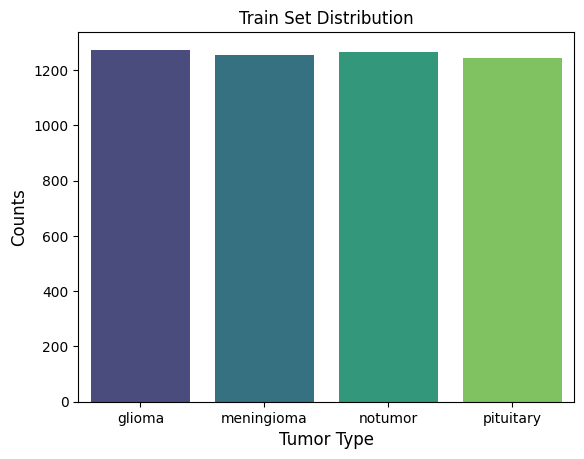

<Figure size 640x480 with 0 Axes>

In [79]:
# Plot train counts
eda.plot_counts('train')
plt.savefig('training_distribution.png', dpi=300, bbox_inches="tight")

/tmp/ipython-input-1996626355.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X, y=y, palette='viridis') # Changed from sns.countplot to sns.barplot


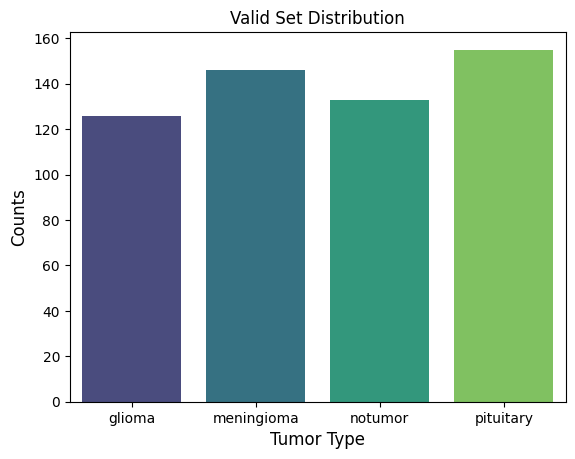

<Figure size 640x480 with 0 Axes>

In [80]:
# Plot validation counts
eda.plot_counts('valid')
plt.savefig('valid_distribution.png', dpi=300, bbox_inches="tight")

/tmp/ipython-input-1996626355.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X, y=y, palette='viridis') # Changed from sns.countplot to sns.barplot


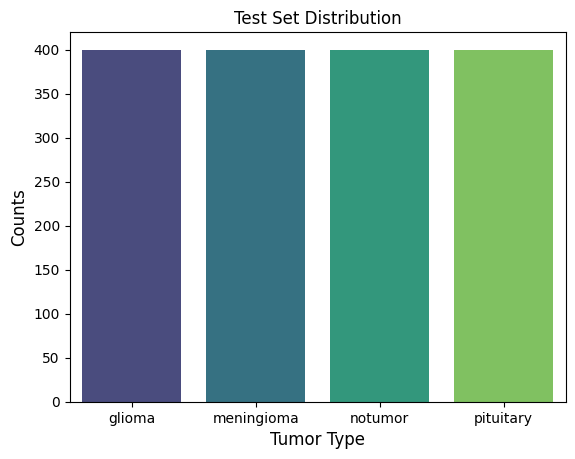

<Figure size 640x480 with 0 Axes>

In [81]:
# Plot test count
eda.plot_counts('test')
plt.savefig('testing_distribution.png', dpi=300, bbox_inches="tight")

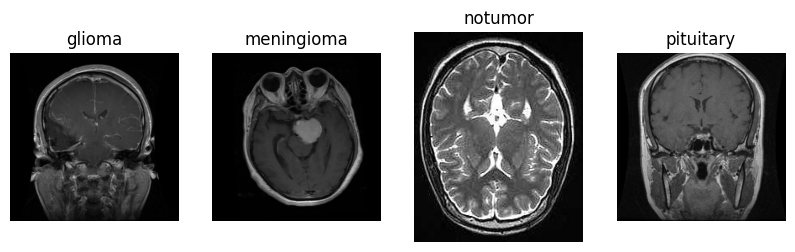

<Figure size 640x480 with 0 Axes>

In [82]:
# Plot samples
eda.plot_samples()
plt.savefig('sample_tumor_types.png', dpi=300, bbox_inches="tight")

## Preprocess data

In [25]:
class Config:
    batch_size = 32
    epochs = 50
    lr = 1e-4
    n_classes = len(CLASSES)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
## Define MONAI transform to "prepare/augment" train/test/val datasets
train_transform = Compose([
    lambda x: np.array(x.convert("RGB")),
    EnsureChannelFirst(channel_dim=-1),
    Resize(spatial_size=(224, 224)),
    ScaleIntensity(),
    RandRotate(range_x=np.pi / 12, prob = 0.5, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5)
])

# Transform validation dataset
val_transformation = Compose([
    lambda x: np.array(x.convert("RGB")),
    EnsureChannelFirst(channel_dim=-1), # Moved EnsureChannelFirst before Resize
    Resize(spatial_size=(224, 224)),
    ScaleIntensity() # No use Rotation or Flip, we want to see how good our image is performing under "real" condition after learning through tons of flipping and rotating images
])

y_pred_trans = Compose([
    Activations(softmax=True)
])
y_trans = Compose([
    AsDiscrete(to_onehot=num_classes)
])

In [27]:
# Create dataset
train_dataset = ImageFolder(TRAINING_FOLDER, transform=train_transform)
val_dataset = ImageFolder(VAL_FOLDER, transform=val_transformation)
test_dataset = ImageFolder(TESTING_FOLDER, transform=val_transformation)

# Make sure all of the labels are in the correct order
assert train_dataset.classes == val_dataset.classes == test_dataset.classes
print(train_dataset.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [28]:
# Define DenseNet model and optimizer
dense_model = DenseNet121(spatial_dims=2, in_channels=3, out_channels=num_classes).to(device)
loss_function = torch.nn.CrossEntropyLoss() # Calculate how far off the models' prediction from the real answer
optimizer = torch.optim.Adam(dense_model.parameters(), lr = Config.lr)
max_epochs= 5
val_interval = 1
auc_metric = ROCAUCMetric()

In [29]:
class EarlyStopping():
    """
    Create an early stopping callback that will stop the training
    and restore the best weights when a certain patience interval is hit.
    """

    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ''

    def __call__(self, model, val_loss):
        if self.best_loss == None: # Save the current loss as the "best" and keeps a copy of the model
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model)
        elif self.best_loss - val_loss > self.min_delta: # if the model get better by significant amount?
            self.best_loss = val_loss # update best loss
            self.counter = 0 # Reset counter to 1
            self.best_model.load_state_dict(model.state_dict()) # Save new best model weights
        elif self.best_loss - val_loss < self.min_delta: # If the model stays the same or got worse
            self.counter +=1
            if self.counter >= self.patience: # Counter reaches patience limit
                self.status = f"Stopped on {self.counter}"
                if self.restore_best_weights: # Restore best weights
                    model.load_state_dict(self.best_model.state_dict())
                return True
        self.status = f'{self.counter}/{self.patience}'
        return False

In [34]:
class BrainTumorClassifier:
    def __init__(self, model, optimizer, criterion, val_transformations, train_dataset, config, output_folder=None):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.output_folder = 'torch_models/' if output_folder is None else output_folder
        self.history = {}
        self.val_transformations = val_transformations
        self.classes = train_dataset.classes
        self.Config = config

    def train(self, training_loader, eval_loader, num_epochs, output_filename):
        """
        Method to train the model for a given number of epochs using the provided training and evaluation data loaders

        Args:
            training_loader (torch.utils.data.dataloader.DataLoader): PyTorch data loader for training data
            eval_loader (torch.utils.data.dataloader.DataLoader): PyTorch data loader for evaluation data
            num_epochs (int): Number of epochs to train the model.
            output_filename (str): Name of file to save the trained model to.

        Returns:
            None. Trains the model and saves it to the specified output directory
        """

        # Create output directory
        if not os.path.exists(self.output_folder):
            os.makedirs(self.output_folder)
        file_dir = os.path.join(self.output_folder, output_filename)

        # Initialize metrics
        train_accuracies, train_losses = [], []
        val_accuracies, val_losses = [], []

        # Define early stopping variables
        early_stopper = EarlyStopping()
        best_epoch = 0
        best_val_loss = np.inf

        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")

            #Train one epoch
            train_acc, train_loss = self._train_epoch(training_loader)
            train_accuracies.append(train_acc)
            train_losses.append(train_loss)

            #Eval one epoch
            val_acc, val_loss = self._eval_epoch(eval_loader)
            val_accuracies.append(val_acc)
            val_losses.append(val_loss)

            print()

            #Update the best model weights
            if val_loss < best_val_loss:
                best_val_loss = val_loss #Update the best val loss
                best_epoch = epoch+1 # Update best epoch for best val loss

            # Check for early stopping
            if early_stopper(self.model, val_loss):
                print(f"Validation loss has not improved for {early_stopper.patience} epochs. Early Stopping...")
                print(f"Reverting back to weights for epoch {best_epoch}.")
                break

            # End of training
            print("Training finished!")

            # Save model
            torch.save(self.model.state_dict(), file_dir)

            # Get history
            self.history = {
                'accuracy': {'train': train_accuracies, 'eval': val_accuracies},
                'loss': {'train': train_losses, 'eval': val_losses}
            }

    def plot_training(self):
        """
        Plots the training and validation accuracy and loss over each epoch. Retrieves the accuracy and loss
        values from the `self.history` dictionary and creates two subplots to display the accuracy and loss
        data separately.
        """

        # Get the accuracies and loss values from self.history
        train_accuracies = self.history['accuracy']['train']
        val_accuracies = self.history['accuracy']['eval']
        train_losses = self.history['loss']['train']
        val_losses = self.history['loss']['eval']

        # Create subplots for accuracies and loss plots
        fig, axs = plt.subplots(2, 1, figsize = (10, 6))
        fig.subplots_adjust(hspace = 0.5)

        # Plot training and validation accuracies
        axs[0].plot(train_accuracies, label = 'Training accuracy')
        axs[0].plot(val_accuracies, label = 'Validation accuracy')
        axs[0].set_title("Accuracy")
        axs[0].set_xlabel("Epoch")
        axs[0].set_ylabel("Accuracy")
        axs[0].legend()

        # Plot training and validation losses
        axs[1].plot(train_losses, label = 'Training losses')
        axs[1].plot(val_losses, label = "Validation losses")
        axs[1].set_title("Loss")
        axs[1].set_xlabel("Epoch")
        axs[1].set_ylabel("Loss")
        axs[1].legend()

        plt.show()

    def evaluate(self, test_loader):
        """
        Evaluates the model on a given test loader and returns the accuracy and loss metrics.
        Uses the 'eval_epoch' method to calculate the metrics for each batch in the loader and returns the fina
        metrics for the entire dataset.

        Args:
            test_loader (torch.utils.data.dataloader.DataLoader): PyTorch DataLoader for the test dataset

        Returns:
            Tuple of the average accuracy and loss the dataset
        """
        return self._eval_epoch(test_loader, return_metrics= True)

    def predict(self, img):
        """
        Takes an image and returns the predicted class label. Applies the validation transformations to the
        image, performs a forward pass through the model, and returns the predicted class.

        Args:
            img: PIL image object of the input image
        Returns:
            The predicted class label as a string
        """
        self.model.eval()
        img = self.val_transformations(img)
        img = torch.unsqueeze(img, 0)
        img = img.to(self.Config.device)
        pred = self.model(img)
        pred_idx = torch.argmax(pred, dim=1)
        return self.classes[pred_idx]

    def _train_epoch(self, training_loader):
        """
        Train a single epoch of the model

        Args:
            training_loader (torch.utils.data.DataLoader): The PyTorch data loader object for the training set

        Returns:
            Tuple of floats: The average training accuracy and avergae training loss for the epoch.
        """
        running_loss = 0.00
        running_acc = 0.00
        self.model.train()

        prog_bar = tqdm(enumerate(training_loader), total = len(training_loader))
        for batch_idx, (imgs, labels) in prog_bar:

            # Configure to device
            imgs, labels = imgs.to(self.Config.device), labels.to(self.Config.device)

            # Zero out gradients
            self.optimizer.zero_grad()

            # Forward pass
            outputs = self.model(imgs)
            loss = self.criterion(outputs, labels)

            #Backward pass
            loss.backward()
            self.optimizer.step()

            # Calculate loss of batch in average
            running_loss += loss.item()

            # Calculate accuracy
            running_acc += (outputs.argmax(-1) == labels).float().mean().item()
            avg_loss = running_loss / (batch_idx + 1)
            avg_acc = running_acc / (batch_idx + 1)

            prog_bar.set_description(f" Batch {batch_idx+1} / {len(training_loader)} - Avg Train Loss: {avg_loss:.4f}, Avg Train Accuracy: {avg_acc:.4f}")
        return avg_acc, avg_loss

    def _eval_epoch(self, eval_loader, return_metrics = True):
        """
        Evaluate the performance of the model on a validation set for a single epoch.

        Args:
            eval_loader (torch.utils.data.dataloader.DataLoader): PyTorch validation loader
            return_metrics (bool): Whether to return the evaluation metrics (accuracy and loss).

        Returns:
            tuple: a tuple containing the evaluation metrics. The first element is the average validation accuracy,
            and the 2nd one  if the average validation loss.
        """

        running_loss = 0.00
        running_acc = 0.00

        self.model.eval()
        prog_bar = tqdm(enumerate(eval_loader), total = len(eval_loader))
        for batch_idx, (imgs, labels) in prog_bar:

            # Configure to device
            imgs, labels = imgs.to(self.Config.device), labels.to(self.Config.device)

            # Forward pass
            outputs = self.model(imgs)
            loss = self.criterion(outputs, labels)

            # Calculate the loss of batch in average
            running_loss += loss.item()

            # Calculate accuracy
            running_acc += (outputs.argmax(-1) == labels).float().mean().item()

            avg_loss = running_loss / (batch_idx+1)
            avg_acc = running_acc / (batch_idx+1)

            prog_bar.set_description(f"Batch {batch_idx+1}/{len(eval_loader)} - Avg Val Loss: {avg_loss:.4f}, Avg Val Accuracy: {avg_acc:.4f}")

        if return_metrics:
            return avg_acc, avg_loss

In [35]:
# Create the "trainer" instance

trainer = BrainTumorClassifier(model=dense_model, optimizer=optimizer,
                                criterion = loss_function, val_transformations = val_transformation,
                                train_dataset=train_dataset, config=Config, output_folder="../models/densenet_v1/")

# Start the training
# 1. Create the Loaders
train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.batch_size, shuffle=False)

# 2. Start the Training (Notice the names must match the Class definition)
trainer.train(
    training_loader = train_loader,
    eval_loader = val_loader,
    num_epochs = Config.epochs,
    output_filename = "best_model.pth"
)

Epoch 1/50


  0%|          | 0/158 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]


Training finished!
Epoch 2/50


  0%|          | 0/158 [00:00<?, ?it/s]

...

  0%|          | 0/18 [00:00<?, ?it/s]


Training finished!
Epoch 18/50


  0%|          | 0/158 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]


Validation loss has not improved for 5 epochs. Early Stopping...
Reverting back to weights for epoch 13.


In [36]:
# Save the results so we don't lose them
history_df = pd.DataFrame(trainer.history)
history_df.to_csv("history.csv", index = False)

### Visualize training

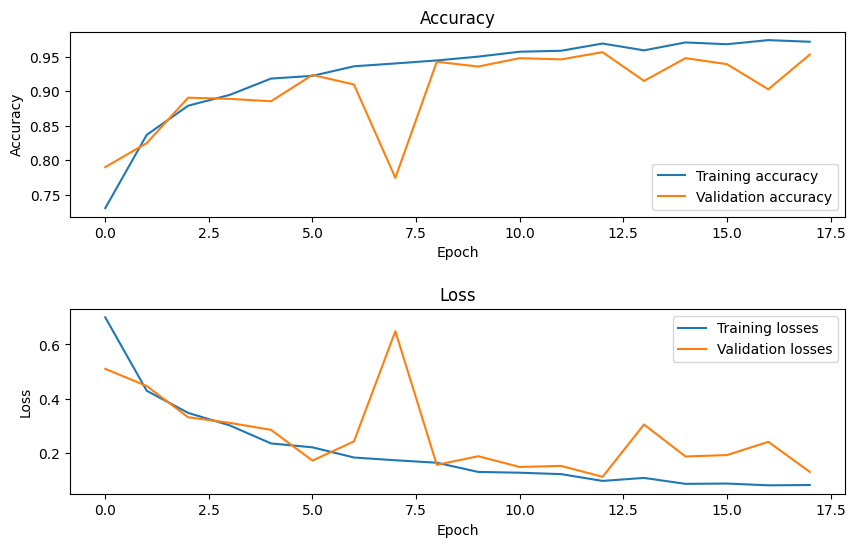

<Figure size 640x480 with 0 Axes>

In [65]:
trainer.plot_training()

# Save
plt.savefig("training_acc_loss", dpi = 300, bbox_inches='tight')
plt.show()

### Evaluate on testing data

In [83]:
test_loader = DataLoader(test_dataset, batch_size=Config.batch_size)

In [39]:
# Testing our model on testing dataset
test_acc, test_loss = trainer.evaluate(test_loader)

print(f"---Final Test Report---")
print(f"Test Accuracy: {test_acc *100:.4f}")
print(f"Test Loss: {test_loss * 100:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

---Final Test Report---
Test Accuracy: 91.5000
Test Loss: 41.1382


In [40]:
# Get the last values from the history lists
final_train_acc = trainer.history['accuracy']['train'][-1]
final_train_loss = trainer.history['loss']['train'][-1]

final_val_acc = trainer.history['accuracy']['eval'][-1]
final_val_loss = trainer.history['loss']['eval'][-1]

print(f"---Final Results---")
print(f"Training Accuracy: {final_train_acc *100:.4f}")
print(f"Training Loss: {final_train_loss * 100:.4f}")
print(f"Validation Accuracy: {final_val_acc *100:.4f}")
print(f"Training Loss: {final_val_loss *100:.4f}")


---Final Results---
Training Accuracy: 97.1717
Training Loss: 8.2763
Validation Accuracy: 95.3125
Training Loss: 13.1109


### Classification Reports and Confusion Matrix

---Gathering predictions---
---Classification Report---
              precision    recall  f1-score   support

      glioma       0.98      0.78      0.87       400
  meningioma       0.89      0.91      0.90       400
     notumor       0.86      0.98      0.92       400
   pituitary       0.95      0.98      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.92      0.91      1600



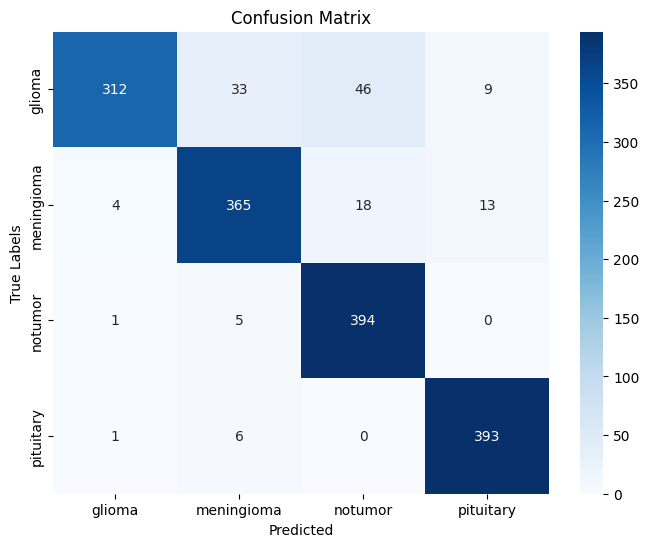

In [64]:
# Plotting classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


def detailed_report(trainer, test_loader):
  trainer.model.eval()

  all_preds = []
  all_labels =[]

  print("---Gathering predictions---")
  with torch.no_grad():
    for imgs, labels in test_loader:
      imgs = imgs.to(trainer.Config.device)
      outputs = trainer.model(imgs)
      preds = torch.argmax(outputs, dim = 1)

      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  return all_preds, all_labels

# Run the function to get predictions and labels
all_preds, all_labels = detailed_report(trainer, test_loader)

# 1. Print classification report
print("---Classification Report---")
print(classification_report(all_labels, all_preds, target_names=test_loader.dataset.classes))

# 2. Confustion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_loader.dataset.classes,
            yticklabels=test_loader.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()


**Classification Report:**

**Overall Accuracy**: The model achieved an overall accuracy of 92% on the test set, which is quite good.
- Glioma: The model shows high precision (0.98), meaning when it predicts 'glioma', it's usually correct. However, its recall (0.78) is a bit lower, indicating it missed identifying some actual 'glioma' cases. The F1-score is 0.87.
- Meningioma: The model performs well with 0.89 precision and 0.91 recall, resulting in a good F1-score of 0.90.
- No Tumor: This class has excellent recall (0.98), meaning most 'no tumor' cases are correctly identified, but slightly lower precision (0.86), indicating it sometimes misclassifies other tumor types as 'no tumor'. The F1-score is 0.92.
- Pituitary: The model performs very well on this class, with high precision (0.95) and recall (0.98), leading to an F1-score of 0.96.

**Confusion Matrix:** This matrix gives a more granular view of correct and incorrect predictions:

- Glioma (row 0): Out of 400 actual glioma cases, 312 were correctly classified. 33 were mistaken for meningioma, 46 for no tumor, and 9 for pituitary.
- Meningioma (row 1): 365 out of 400 actual meningioma cases were correctly classified. It misclassified 4 as glioma, 18 as no tumor, and 13 as pituitary.
- No Tumor (row 2): This class has the highest recall with 394 out of 400 cases correctly identified. Only 1 was mistaken for glioma and 5 for meningioma.
- Pituitary (row 3): 393 out of 400 actual pituitary cases were correctly classified. It only misclassified 1 as glioma and 6 as meningioma.

Overall, even though the model can be improved more, the performance is generally quite good.

In [ ]:
# 1. Recreate the model skeleton
dense_model = DenseNet121(spatial_dims=2, in_channels=3, out_channels=num_classes).to(Config.device)

# 2. Load the saved weights
model_path = "/content/models/densenet_v1/best_model.pth"
# Load the weights
dense_model.load_state_dict(torch.load(model_path, map_location=Config.device))

# Set to evaluation mode
dense_model.eval() # Tells layer (dropout or BatchNorm) stops training, otherwis => inconsistencies whenever rerun

print("Model loaded and ready for prediction")

### Using Grad-Cam to highlight exactly which pixels in the MRI scan to convince the model to make the predictions.

In [ ]:
# Make sure to install Grad-Cam
# "!pip install grad-cam" if you are using Google Colab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=d529d372f26dd8a4c58cc369e7e0b6816188208395272cbcfc8f114b463cc1f8
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


If we can see the heatmap on the tumor, our model is reliable.
If the heatmap is on the edges of the images: the model might be underfitting or biased

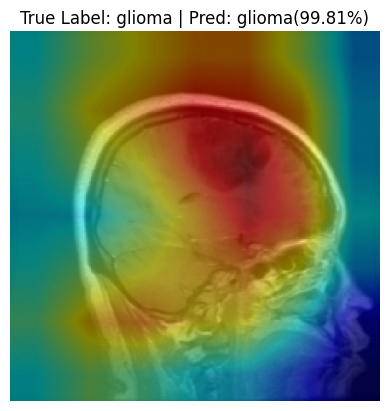

In [62]:
# Import dependencies necessary

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def generate_gradcam(model, input_tensor, input_image, target_category=None):
  """
  Args:
    model: our trained DenseNet121
    input_tensor: the 4D tensor (1, 3, 224, 224)
    input_image: the original image normalized to [0, 1] for visualization
    target_category: the index of the class you want to explain (e.g., 0 for glioma)
  """

  # Define the target layer
  target_layers = [model.features[-2]] # Changed target layer to the last BatchNorm2d for DenseNet121

  # 2. Initialize GradCAM
  cam = GradCAM(model=model, target_layers=target_layers)

  # 3. If target_category is None, it'll use the highest scoring category
  targets = [ClassifierOutputTarget(target_category)] if target_category is not None else None
  # If no category, default to the highest scoring class

  # 4. Generate mask
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
  grayscale_cam = grayscale_cam[0, :] # Take the first image in batch

  # 5.Overlay the heatmap on the original image
  visualization = show_cam_on_image(input_image, grayscale_cam, use_rgb=True)

  return visualization

# Use 1 image from the test dataset
dense_model.eval()
img_tensor, label = test_dataset[60] # Takes a random image and its true label from the dataset
input_tensor = img_tensor.unsqueeze(0).to(Config.device) # (1, 3, 224, 224)

# Prepare background image for display
rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

# Run Grad-CAM
cam_image = generate_gradcam(dense_model, input_tensor, rgb_img)


# Get the model's raw output
with torch.no_grad():
  output = dense_model(input_tensor)
  predicted_class_idx = torch.argmax(output, dim=1).item()
  confidence = torch.nn.functional.softmax(output, dim=1)[0][predicted_class_idx].item() *100

predicted_label = test_dataset.classes[predicted_class_idx]
true_label = test_dataset.classes[label]
# Display
plt.imshow(cam_image)
plt.title(f"True Label: {true_label} | Pred: {predicted_label}({confidence:.2f}%)")
plt.axis('off')
plt.savefig("brain_tumor_gradcam", dpi = 300, bbox_inches='tight')
plt.show()